In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from utils.networks import Network
from utils.evaluation import  WassersteinDistance1D
from samplers.sample1d import DPSGLD1D
from tqdm import  tqdm

# Sampling in $\mathbb{R}$

We want to sample from $\pi(x)\propto e^{-U(x)}\mathbf{1}_{\mathcal{K}}(x)$, where $\mathcal{K}= [-R, R]$ (we take $R=1$). In this example, we use $U(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx$ with $\mu=1.0, \beta=0.5$, and $b=1$.

In [2]:
def global_potential(x, mu=1.0, beta=0.5, b=1.0):
    f = 0.5*mu*x**2 + 0.25*beta*x**4 - b*x
    return f

In [3]:
# pi on grid
def true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001):
    x = np.linspace(-R, R, n_grid)
    logp = -global_potential(x, mu, beta, b)
    logp -= logp.max()                          # Stabilize
    p_unn = np.exp(logp)
    dx = x[1] - x[0]
    Z = p_unn.sum() * dx
    pdf = p_unn / Z
    return x, pdf

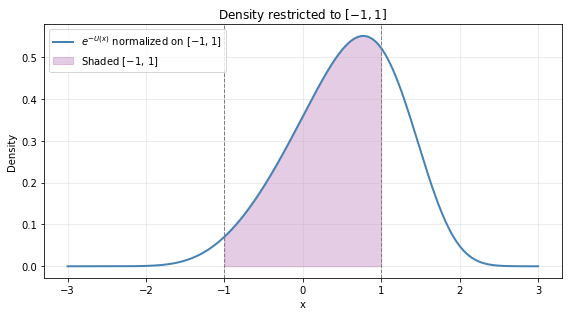

In [4]:
# Parameters 
mu, beta, b = 1.0, 0.5, 1.0
R, n_grid = 1.0, 40001
shade_a, shade_b = -R, R

x, pdf = true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001)
xx = np.linspace(-3,3, n_grid)
expU_unn = np.exp(-global_potential(xx, mu, beta, b))
dx = xx[1] - xx[0]
Z_exp = expU_unn.sum() * dx
expU_pdf = expU_unn / Z_exp   # normalized on [-1,1]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(xx, expU_pdf, color='steelblue', lw=2, label=r'$e^{-U(x)}$ normalized on $[-1,1]$')
ax.fill_between(xx, expU_pdf, 0.0, where=(xx>=shade_a) & (xx<=shade_b),
                color='purple', alpha=0.2, label=r'Shaded $[-1,\,1]$')
ax.axvline(-1, color='gray', ls='--', lw=1)
ax.axvline( 1, color='gray', ls='--', lw=1)
ax.set_title(r'Density restricted to $[-1,1]$')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


However, instead of $U(x)$, we use a proximal function in the potential:

$$\pi^{\gamma}(x)\propto e^{-U^{\gamma}(x)}$$

where, $U^{\gamma}(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx+\frac{1}{2\gamma}(x-\Pi(x))^2$, and $\Pi(x)$ is the projection on to the box $\mathcal{K}=[-1,1]$.

Once we sample, we then compute the 2-Wasserstein distance in 1 dimension based on the definition by Panaretos et. al,

$$\mathcal{W}_2^2(\mu, \nu) = \int_0^1 (F^{-1}_{\mu}(u)-F^{-1}_{\nu}(u))^2 du\approx \frac1n\sum_{k=1}^n (Q(u_k)-x^{(k)}),\quad u_k=\frac{k-\frac12}{n}$$

where, $Q=F^{-1}$ is the true quantile of the target on $[-R, R]$, and $x^{(k)}$ are stored samples at the $k$th iteration.

### True target quantile function $Q(u)$ for $\pi(x)\propto e^{-f(x)}\mathbf{1}_{[-R, R]}$

In [5]:
def make_target_quantile(R, mu=1.0, beta=0.5, b=1.0, grid_size=200_001):
    """
    Returns a collable Q(u)=F^{-1}(u) for the truncated target on [-R, R].
    Uses a dense grid + stabilized exp + trapezoidal CDF + monotone inversion
    """
    x = np.linspace(-R, R, grid_size)
    f = 0.5 * mu * x**2 + 0.25 * beta * x**4 - b * x 
    # Stabilize exp(-f)
    logw = -f 
    logw -= logw.max()
    w = np.exp(logw)
    
    # Trapezoid cumulative integral to get unnormalized CDF
    dx = x[1] - x[0]
    cdf_unnormalized = np.cumsum((w[:-1] + w[1:]) * 0.5) * dx 
    cdf_unnormalized = np.concatenate(([0.0], cdf_unnormalized))
    
    Z = cdf_unnormalized[-1]
    if not np.isfinite(Z) or Z <= 0:
        raise RuntimeError("Normalization failed; check parameters/grid size.")
    
    cdf = cdf_unnormalized / Z 
    
    # Monotone inversion
    cdf = np.maximum.accumulate(cdf)
    cdf[0] = 0.0 
    cdf[1] = 1.0
    
    def Q(u):
        u = np.asarray(u)
        u = np.clip(u, 0.0, 1.0)
        return np.interp(u, cdf, x)
    
    return Q

In [6]:
Q = make_target_quantile(R=R)

Define the run and plot

In [7]:
def dpsgld_sampling_run(
    Q,                  # Quantile of the target distribution
    size_w = 100,       # Size of the doubly stochastic matrix or mixing matrix (Tune)
    N = 100,            # Number of of samples to be generated in each iteration (Tune)
    n_steps=150,        # Number of iterations (Tune)
    eta = 5e-4,         # Learning Rate (Tune)
    sigma_grad = 0.5,   # Langevin noise scale
    gamma=1e-3,         # Proximal regulator (Tune)
    R = 1.0,            # Boundary of the constrained domain (Tune)
    nets = ("fcn", "cn", "sn", "fdn"),
    seed = 121,
    figsize = (36, 8),
    logy = False
):
    fig, axes = plt.subplots(1,4, figsize=figsize, sharey=False)
    network_names=["Fully Connected", "Circular", "Star", "Disconnected"]
    
    for ax, net, names in zip(axes, nets, network_names):
        sampler = DPSGLD1D(
            size_w=size_w, N=N, n_steps=n_steps,
            eta=eta, gamma=gamma, sigma_grad=sigma_grad,
            net=net, R=R, seed=seed
        )
        history_all, X_mean_all = sampler.sample()
        dist = WassersteinDistance1D(
            history_all=history_all, X_mean_all=X_mean_all
        )
        w2dis = dist.W2dist(Q)
        
        agent_ids = np.sort(random.sample(range(1, size_w),3))
        for i in agent_ids:
            ax.plot(w2dis[i], label=f"Agent {i}", alpha=0.9, linewidth=3)
        ax.plot(w2dis[-1], label=f"Mean", alpha=0.9, linewidth=3)
    
        ax.set_title(names, fontsize=24)
        ax.grid(True, alpha=0.25)
        ax.set_xlabel("Iteration", fontsize=24)
        ax.set_ylabel(r"$\mathcal{W}_2$", fontsize=24)
        if logy:
            ax.set_yscale("log")
        ax.legend(loc="best", fontsize=24)
            
    plt.tight_layout()
    plt.show()

In [ ]:
dpsgld_sampling_run(Q=Q, size_w=50, N=100, n_steps=150, gamma=1e-2, eta=5e-4)

  2%|▏         | 3/150 [00:06<05:18,  2.17s/it]